In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
import pickle
import warnings
warnings.filterwarnings("ignore")

C:\Users\Muskan\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("Hello-SimpleAI/HC3", "all")
print("Dataset downloaded successfully!")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Generating train split: 100%|██████████| 24322/24322 [00:00<00:00, 131741.96 examples/s]

Dataset downloaded successfully!


In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'human_answers', 'chatgpt_answers', 'source'],
        num_rows: 24322
    })
})


In [4]:
df = dataset["train"].to_pandas()
print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (24322, 5)


,id,question,human_answers,chatgpt_answers,source
0,0,"Why is every book I hear about a "" NY Times # ...","[Basically there are many categories of "" Best...",[There are many different best seller lists th...,reddit_eli5
1,1,"If salt is so bad for cars , why do we use it ...",[salt is good for not dying in car crashes and...,[Salt is used on roads to help melt ice and sn...,reddit_eli5
2,2,Why do we still have SD TV channels when HD lo...,[The way it works is that old TV stations got ...,[There are a few reasons why we still have SD ...,reddit_eli5
3,3,Why has nobody assassinated Kim Jong - un He i...,[You ca n't just go around assassinating the l...,[It is generally not acceptable or ethical to ...,reddit_eli5
4,4,How was airplane technology able to advance so...,[Wanting to kill the shit out of Germans drive...,[After the Wright Brothers made the first powe...,reddit_eli5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24322 entries, 0 to 24321
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               24322 non-null  object
 1   question         24322 non-null  object
 2   human_answers    24322 non-null  object
 3   chatgpt_answers  24322 non-null  object
 4   source           24322 non-null  object
dtypes: object(5)
memory usage: 950.2+ KB


In [6]:
print(df.isnull().sum())

id                 0
question           0
human_answers      0
chatgpt_answers    0
source             0
dtype: int64


In [7]:
print("Question:\n")
print(df.loc[0, "question"])
print("\nHuman Answer:\n")
print(df.loc[0, "human_answers"])
print("\nChatGPT Answer:\n")
print(df.loc[0, "chatgpt_answers"])

Question:

Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear about a " NY Times # 1 Best Seller " ? Should n't there only be one " # 1 " best seller ? Please explain like I'm five.

Human Answer:

['Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you \'re still an " oscar - winning " film . Same thing for best sellers . Also , IIRC the rankings change every week or something like that . Some you might not be best seller one week , but you may be the next week . I guess even if you do n\'t stay there for long , you still achieved the status . Hence , # 1 best seller .'
 "If you 're hearing about it , it 's because it was a very good or very well - publicized book ( or both ) , and almost every good or well - publicize

In [8]:
texts = []
labels = []

for _, row in df.iterrows():

    # Human Answers
    for answer in row["human_answers"]:
        texts.append(answer)
        labels.append("human")

    # ChatGPT Answers
    for answer in row["chatgpt_answers"]:
        texts.append(answer)
        labels.append("ai")

# Create DataFrame
new_df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("New Dataset Shape :", new_df.shape)
new_df.head()

New Dataset Shape : (85449, 2)


,text,label
0,"Basically there are many categories of "" Best ...",human
1,"If you 're hearing about it , it 's because it...",human
2,"One reason is lots of catagories . However , h...",human
3,There are many different best seller lists tha...,ai
4,salt is good for not dying in car crashes and ...,human


In [9]:
print(new_df["label"].value_counts())

label
human    58546
ai       26903
Name: count, dtype: int64


In [10]:
# Separate Human and AI samples
human_df = new_df[new_df["label"] == "human"]
ai_df = new_df[new_df["label"] == "ai"]
# Randomly sample Human texts to match AI count
human_df = human_df.sample(
    n=len(ai_df),
    random_state=42
)
# Combine both datasets
balanced_df = pd.concat([human_df, ai_df])
# Shuffle the dataset
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced Dataset Shape :", balanced_df.shape)
balanced_df["label"].value_counts()

Balanced Dataset Shape : (53806, 2)


label
ai       26903
human    26903
Name: count, dtype: int64

In [11]:
balanced_df.to_csv(
    "balanced_ai_human_dataset.csv",
    index=False
)
print("Balanced dataset saved successfully!")

Balanced dataset saved successfully!


In [13]:
balanced_df.head()

,text,label
0,The Holocaust was a horrific event in history ...,ai
1,Plants and animals don't create poison out of ...,ai
2,It is not appropriate for me to provide medica...,ai
3,Base jumping is an extreme sport in which indi...,ai
4,"Yes, it is possible to purchase a new Toyota d...",ai


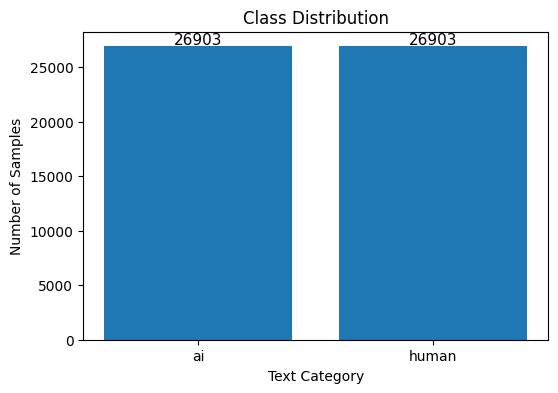

In [14]:
label_counts = balanced_df["label"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Text Category")
plt.ylabel("Number of Samples")
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 200, str(count), ha="center", fontsize=11)
plt.show()

In [15]:
print("Missing Values:\n")
print(balanced_df.isnull().sum())

Missing Values:

text     0
label    0
dtype: int64


In [16]:
def clean_text(text):
    """
    Clean the input text by:
    1. Converting to lowercase
    2. Removing punctuation
    3. Removing extra spaces
    """
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [17]:
balanced_df["clean_text"] = balanced_df["text"].apply(clean_text)
balanced_df.head()

,text,label,clean_text
0,The Holocaust was a horrific event in history ...,ai,the holocaust was a horrific event in history ...
1,Plants and animals don't create poison out of ...,ai,plants and animals don t create poison out of ...
2,It is not appropriate for me to provide medica...,ai,it is not appropriate for me to provide medica...
3,Base jumping is an extreme sport in which indi...,ai,base jumping is an extreme sport in which indi...
4,"Yes, it is possible to purchase a new Toyota d...",ai,yes it is possible to purchase a new toyota di...


In [18]:
comparison = balanced_df[["text", "clean_text"]]
comparison.head()

,text,clean_text
0,The Holocaust was a horrific event in history ...,the holocaust was a horrific event in history ...
1,Plants and animals don't create poison out of ...,plants and animals don t create poison out of ...
2,It is not appropriate for me to provide medica...,it is not appropriate for me to provide medica...
3,Base jumping is an extreme sport in which indi...,base jumping is an extreme sport in which indi...
4,"Yes, it is possible to purchase a new Toyota d...",yes it is possible to purchase a new toyota di...


In [19]:
label_mapping = {
    "human": 0,
    "ai": 1
}
balanced_df["label"] = balanced_df["label"].map(label_mapping)
print("Label Mapping")
print(label_mapping)

Label Mapping
{'human': 0, 'ai': 1}


In [20]:
X = balanced_df["clean_text"]
y = balanced_df["label"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 43044
Testing Samples  : 10762


In [22]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Training TF-IDF Shape :", X_train_tfidf.shape)
print("Testing TF-IDF Shape  :", X_test_tfidf.shape)

Training TF-IDF Shape : (43044, 5000)
Testing TF-IDF Shape  : (10762, 5000)


In [23]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
y_pred = model.predict(X_test_tfidf)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5381
           1       0.93      0.93      0.93      5381

    accuracy                           0.93     10762
   macro avg       0.93      0.93      0.93     10762
weighted avg       0.93      0.93      0.93     10762



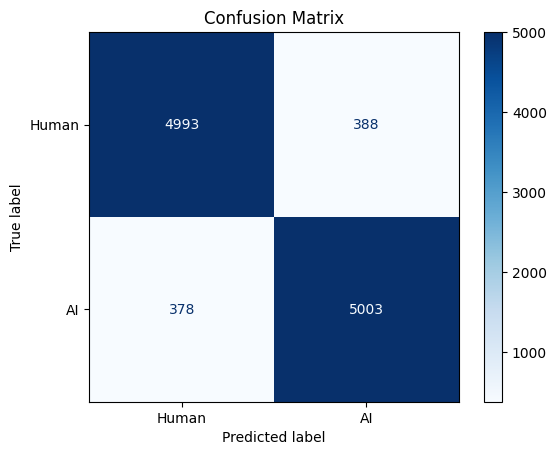

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [27]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
importance_df = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})
importance_df.head()

,Word,Coefficient
0,00,-0.106290
1,000,-0.005699
2,01,-0.060621
3,10,-1.610265
4,100,-1.053480


In [29]:
top_ai_words = importance_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)
print(top_ai_words)

           Word  Coefficient
2297  important    14.374097
2176      helps     9.457427
2310  including     9.449121
2172       help     8.974831
3168    overall     8.180212
3588  questions     6.476681
2669    located     6.046504
4788    variety     5.946790
4724     united     5.840962
3049       nthe     5.747921


In [30]:
top_human_words = importance_df.sort_values(
    by="Coefficient",
    ascending=True
).head(10)
print(top_human_words)

           Word  Coefficient
4753        url   -11.289259
657          ca    -8.831235
448   basically    -8.440820
3442     pretty    -6.859446
3473   probably    -6.453340
4793         ve    -6.122484
2499       just    -5.781375
2057        got    -5.228783
2663         ll    -5.215372
3649     really    -5.132263


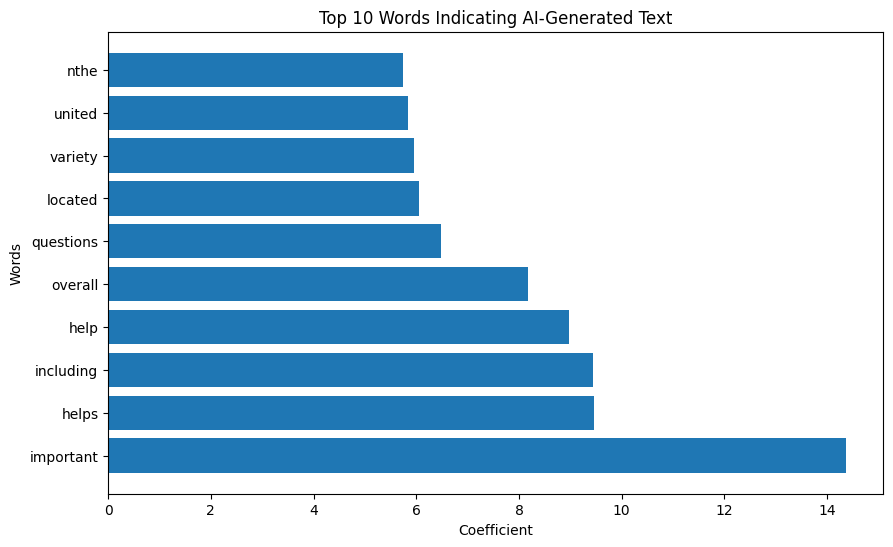

In [31]:
plt.figure(figsize=(10,6))
plt.barh(
    top_ai_words["Word"],
    top_ai_words["Coefficient"]
)
plt.title("Top 10 Words Indicating AI-Generated Text")
plt.xlabel("Coefficient")
plt.ylabel("Words")

plt.show()

In [32]:
import os
os.makedirs("models", exist_ok=True)

# Save model
with open("models/model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save vectorizer
with open("models/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
